In [16]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field
import operator

# Will evaluate Essay on basis of 1)clarity of throught 2) Depth of topic 3) Language and will have to assign the number between 1 to 10.
#Requirement 
1) We need model who can produce structured output and reliable Output



In [8]:
load_dotenv()
model=ChatOpenAI(model='gpt-4o-mini')# because its produce structured output.


In [9]:
class EvaluationSchema(BaseModel): # coming from PyDantic
    feedback:str=Field(description="Detailed Feedback for Essay")
    score:int =Field(description="Score out of 10",ge=0,le =10)

In [10]:
structured_output= model.with_structured_output(EvaluationSchema)

In [11]:
essay="""**Essay on Artificial Intelligence (AI)**

Artificial Intelligence (AI) is one of the most transformative technologies of the modern era. It refers to the ability of machines and computer systems to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, perception, and language understanding. Over the past few decades, AI has evolved from a theoretical concept into a practical tool that is reshaping industries, economies, and everyday life.

The roots of AI can be traced back to the mid-20th century, when pioneers like Alan Turing began exploring whether machines could think. His famous “Turing Test” laid the foundation for evaluating machine intelligence. Since then, advancements in computing power, data availability, and algorithms have accelerated AI development significantly.

AI can be broadly categorized into three types: Narrow AI, General AI, and Superintelligent AI. Narrow AI, also known as weak AI, is designed to perform specific tasks such as voice recognition, recommendation systems, or image classification. Examples include virtual assistants like Siri and Google Assistant. General AI, which is still largely theoretical, aims to replicate human-level intelligence across a wide range of tasks. Superintelligent AI, a concept often discussed in research and science fiction, would surpass human intelligence in all aspects.

The applications of AI are vast and continue to grow. In healthcare, AI helps in early disease detection, drug discovery, and personalized treatment plans. In finance, it is used for fraud detection, credit scoring, and algorithmic trading. In transportation, AI powers self-driving vehicles and traffic management systems. Companies like Tesla are pioneering autonomous driving technologies, while organizations like OpenAI are advancing natural language processing and generative AI.

Despite its benefits, AI also presents several challenges and ethical concerns. One major issue is job displacement, as automation may replace certain types of work. There are also concerns about data privacy, algorithmic bias, and the potential misuse of AI technologies. Ensuring responsible AI development requires strong governance, transparency, and ethical guidelines.

Moreover, AI governance has become an important topic globally. Governments and organizations are working to create frameworks that ensure AI is used safely and fairly. This includes regulating data usage, ensuring accountability in decision-making systems, and preventing harmful applications.

In conclusion, Artificial Intelligence is a powerful and evolving field that holds immense potential to improve human life. While it offers numerous advantages across various sectors, it also demands careful consideration of ethical and societal implications. The future of AI will depend not only on technological advancements but also on how responsibly it is developed and deployed.
"""

In [12]:
prompt="provide the detailed feedback on essay and assign a score"
structured_output.invoke(prompt).feedback 

'The essay begins with a clear thesis statement indicating the main argument; however, it needs more specificity. The structure is generally well organized with distinct paragraphs, each focusing on a specific aspect of the topic. The introduction effectively sets the stage, but the conclusion feels rushed and could better summarize the key points made throughout the essay. \n\nThere are some strong points demonstrated through relevant examples and logical reasoning, but there are also sections where the arguments lack depth. Expanding on these points with additional evidence or counterarguments would strengthen the overall argument.\n\nGrammar and spelling are mostly correct, but there are a few minor errors that could be addressed for improved clarity. The vocabulary used is appropriate for the topic, but varying the language and using more sophisticated terminology could elevate the academic tone of the essay.'

##Creating Agentic Model

In [28]:
class EssayEval(TypedDict):
    essay:str
    lang_feedback:str
    depth_feedback:str
    clarity_feedback:str
    overall_feedback:str
    Individual_score:Annotated[list[int],operator.add]
    #Individula acore will be retaining the score on basis of clarity,depth and language 
    #normally we update the dictionary however individual_score will be list of three which need to appended rather update.
    #since we can not use "+" sign here so using operator 
    avg_score:float
    

In [36]:

def eval_lang(state:EssayEval)->EssayEval:
    prompt=f"Evaluate the language of the following essay and provide a detailed feedback"
    output=structured_output.invoke(prompt)
    return {'lang_feedback':output.feedback,'Individual_score':[output.score]}

def eval_depth(state:EssayEval)->EssayEval:
    prompt=f"Evaluate the depth of the following essay and provide a detailed feedback"
    output=structured_output.invoke(prompt)
    return {'depth_feedback':output.feedback,'Individual_score':[output.score]}

def eval_clarity(state:EssayEval)->EssayEval:
    prompt=f"Evaluate the clarity of the following essay and provide a detailed feedback"
    output=structured_output.invoke(prompt)
    return {'clarity_feedback':output.feedback,'Individual_score':[output.score]}


def combined_details(state:EssayEval)->EssayEval:
    prompt=f"""Based of the following feedbacj generate the final summarized feedback \n
    Language Feedback: \n {state['lang_feedback']}  \n clarity feedback: \n {state['clarity_feedback']} 
    \n depth feedback: \n{state['depth_feedback']}"""
    output=model.invoke(prompt) # because we dont want structured /json output
    overall_feeback=output.content
    avg_score=sum(state['Individual_score'])/len(state['Individual_score'])
    return {'overall_feedback':overall_feeback,'avg_score' :avg_score}

In [37]:
graph=StateGraph(EssayEval)

#adding a nodes
graph.add_node("evaluate language",eval_lang)
graph.add_node("evaluate clarity",eval_clarity)
graph.add_node("evaluate depth",eval_depth)
graph.add_node("final merge",combined_details)
#adding edges
graph.add_edge(START,"evaluate language")
graph.add_edge(START,"evaluate clarity")
graph.add_edge(START,"evaluate depth")
graph.add_edge("evaluate language","final merge")
graph.add_edge("evaluate clarity","final merge")
graph.add_edge("evaluate depth","final merge")
graph.add_edge("final merge",END)

workflow=graph.compile()


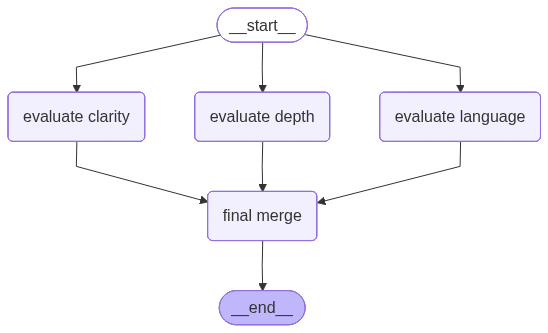

In [38]:
workflow

In [39]:
initial_state={'essay':essay}
workflow.invoke(initial_state)

{'essay': '**Essay on Artificial Intelligence (AI)**\n\nArtificial Intelligence (AI) is one of the most transformative technologies of the modern era. It refers to the ability of machines and computer systems to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, perception, and language understanding. Over the past few decades, AI has evolved from a theoretical concept into a practical tool that is reshaping industries, economies, and everyday life.\n\nThe roots of AI can be traced back to the mid-20th century, when pioneers like Alan Turing began exploring whether machines could think. His famous “Turing Test” laid the foundation for evaluating machine intelligence. Since then, advancements in computing power, data availability, and algorithms have accelerated AI development significantly.\n\nAI can be broadly categorized into three types: Narrow AI, General AI, and Superintelligent AI. Narrow AI, also known as weak AI, is designed t